# The Heat Semigroup for image processing 

##### In this notebook, we show how the [heat semigroup](https://www.math.ucdavis.edu/~hunter/m218a_09/ch5) can be used for image corruption, restoration and compression. 

##### We demonstrate the process on three very different types of images: satellite; cartoon; architectural.  

##### The semigroup and diffusion notebooks are structured in the same manner. It may be interesting to compare the notebooks side by side.

We begin by importing an approximation for the [heat kernel on the square](https://en.wikipedia.org/wiki/Heat_kernel), which is given by one of the [Jacobi-Theta functions](https://en.wikipedia.org/wiki/Theta_function#A_solution_to_the_heat_equation). This will serve as our convolution kernel.

In [1]:
from heatdiff.math import jacobi_theta_2d

By the theory of parabolic equations - the heat equation is a parabolic equation - the time variable has the same scaling factor as the distance squared. Equivalently, the square root of time scales like the distance. As a result, we will choose the time variable to be the square root of the spatial variable for the convolution kernel.

In [2]:
jacobi_9 = jacobi_theta_2d(
    3, 9
)  # we have chosen two integer values but this is not important

### Satellite image

Let us import an image 

In [3]:
from heatdiff.visualization import show_image
from heatdiff.image import normalize_image, load_image

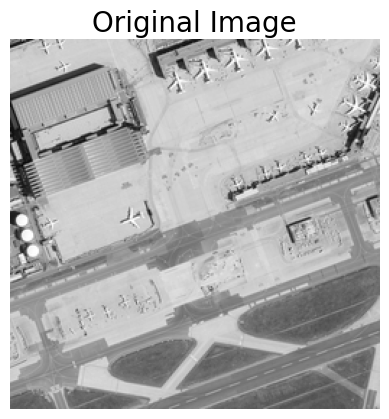

In [4]:
original_img = load_image("images/dop20_32_468_5543_1_he.jpg")
normalised_img = normalize_image(original_img)
show_image(original_img, "Original Image")

Now, we apply the reverse heat semigroup for 10000 steps. Note that the larger the number of steps, the better the approximation to the reverse heat equation and hence a better performance.

We obtain the reverse heat equation via the [reverse Brownian motion](https://en.wikipedia.org/wiki/Wiener_process#Time_reversal). This is possible due to the [Feynman-Kac formula](https://www.stat.uchicago.edu/~lalley/Courses/391/Lecture12.pdf).

In [5]:
from heatdiff.processing import reverse_heat_equation

In [6]:
stl_rev, stl_fwd = reverse_heat_equation(jacobi_9, original_img, 10000)

Let's take a look at how the image is corrupted and then reconstructed. We visualise the first few steps and the final step. Note that the larger the number of steps, the lower the mean squared error between the original image and its reconstruction. Note that for the reconstruction process, the 0th image is the final step.

In [7]:
import matplotlib.pyplot as plt


def plot_images(img, step):
    """
    Plot every k'th image

    Parameters:
    - img (list): input list of images
    - step (int): plot every 'step' size image

    Returns:
    - None: This function displays a plot and does not return any values
    """
    for i in range(0, (len(img)), step):
        show_image(img[i], i)


def subplot_2(image1, image2):
    """
    Plotting two images side by side.

    Parameters:
    - image1 (matrix): matrix representation of an image.
    - image1 (matrix): matrix representation of an image.

    Returns:
    - None: This function displays a plot and does not return any value.
    """
    fig = plt.figure(figsize=(10, 10))

    rows = 2
    columns = 2

    fig.add_subplot(rows, columns, 1)

    plt.imshow(image1, cmap="gray")
    plt.axis("off")
    plt.title("Image 1")

    fig.add_subplot(rows, columns, 2)

    plt.imshow(image2, cmap="gray")
    plt.axis("off")
    plt.title("Image 2")

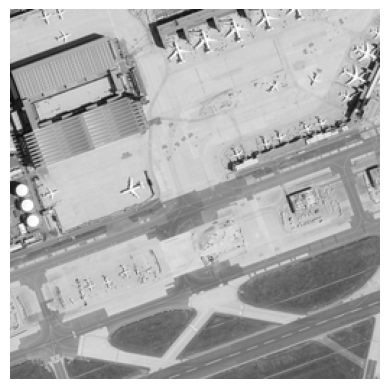

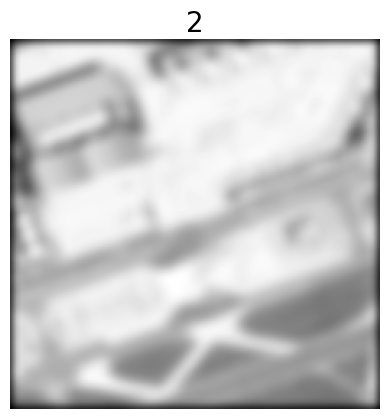

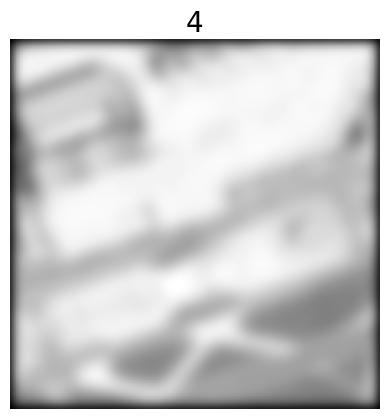

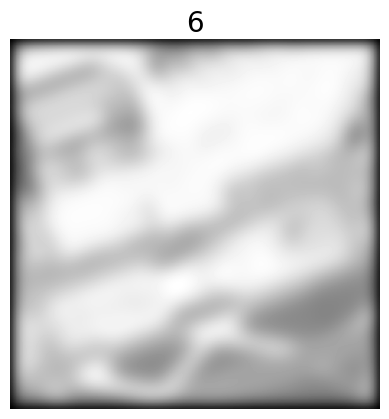

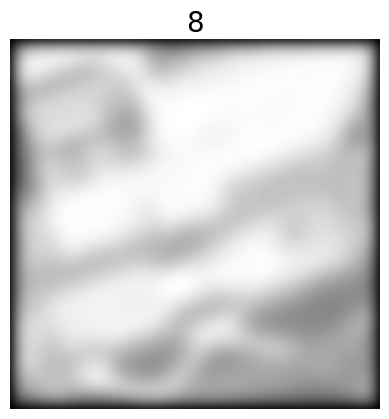

In [8]:
plot_images(stl_fwd[0:10], 2)

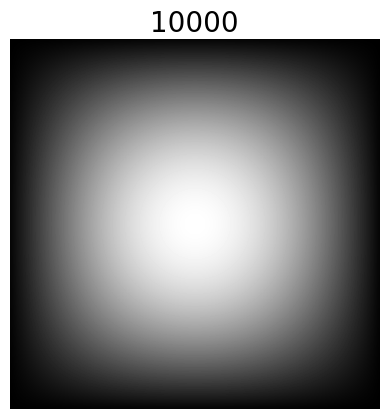

In [9]:
show_image(stl_fwd[-1], "10000")

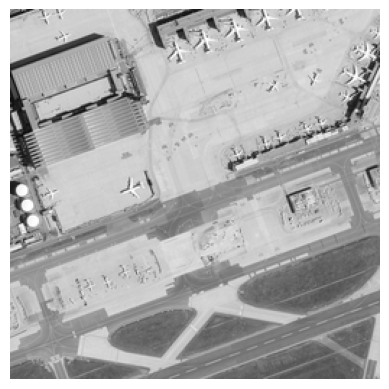

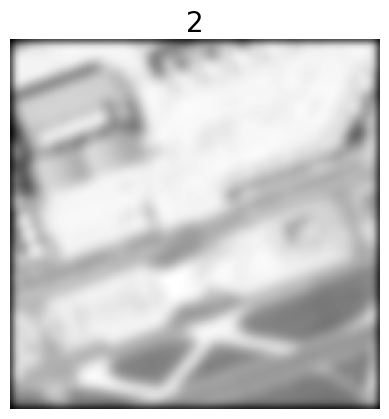

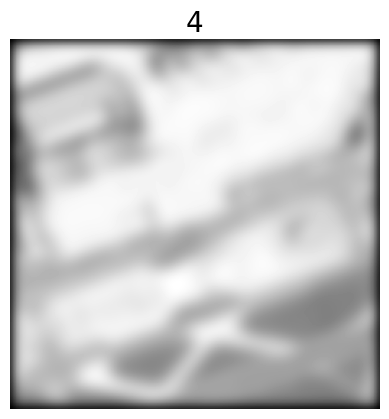

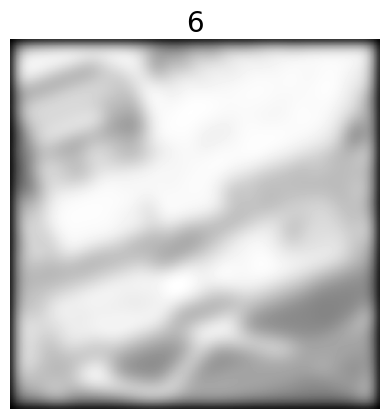

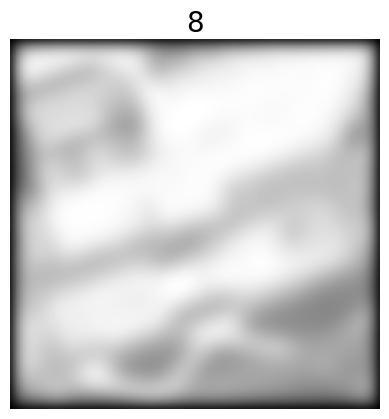

In [10]:
plot_images(stl_rev[0:10], 2)

After putting the reconstructed image into the 0-255 pixel range, let us visually compare the two images and their distributions. 

In [11]:
from heatdiff.image import normal_range
from heatdiff.visualization import compare_norm_histograms

In [12]:
reconstructed_stl = normal_range(stl_rev[0])

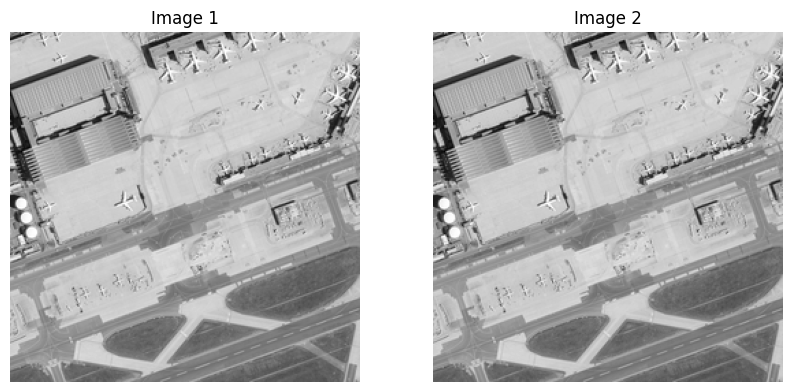

In [13]:
subplot_2(original_img, reconstructed_stl)

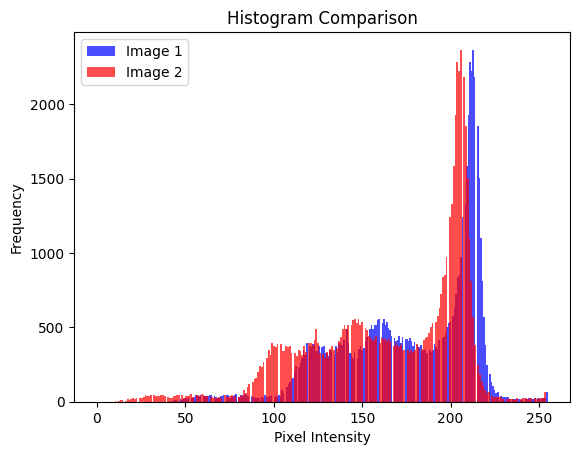

In [14]:
compare_norm_histograms(original_img, reconstructed_stl)

We note that the histograms are quite similar (compare this to the diffusion_demo notebook).

Now, let us compare the mean square error. We will normalise both images so that it makes for a much more interpretable comparison.

In [15]:
from heatdiff.image.image_metrics import mean_squared_error as mse

In [16]:
mse(
    normalised_img, normalize_image(reconstructed_stl)
) * 100  # To have it as a percentage

0.0005504071137149376

As previously stated, increasing the number of steps greatly decreases the mean squared error as well as the visual loss. 

#### Compression 

We will use a weighted K-means to compress the image. We do this by reducing the range of pixel intensity from 256 to 8 (random choice.) The weight in the K-means algorithm is the jacobi theta function, which as we stated, is the approximation of the heat kernel on the square.

In [17]:
from heatdiff import jacobi_compression

In [18]:
compressed_stl, centres = jacobi_compression(reconstructed_stl, 8)

In [19]:
compressed_stl = normal_range(compressed_stl)

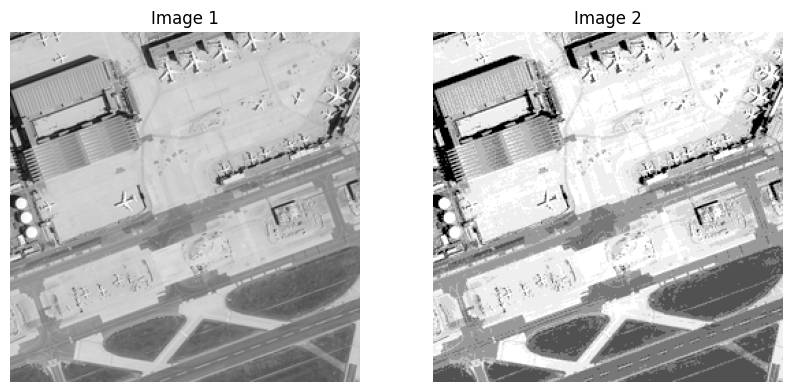

In [20]:
subplot_2(original_img, compressed_stl)

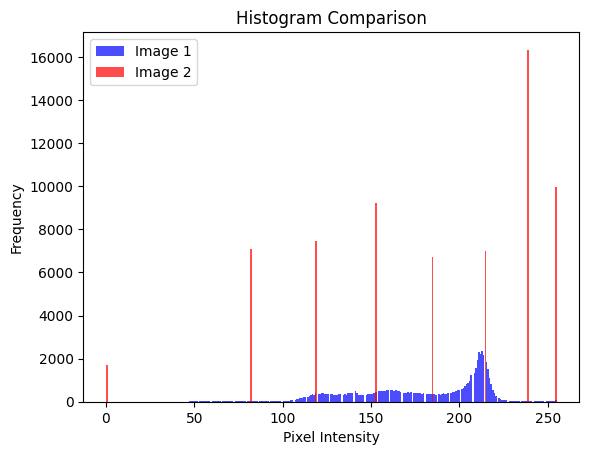

In [21]:
compare_norm_histograms(original_img, compressed_stl)

Lets check the mean squared error. 

In [22]:
(
    mse(normalised_img, normalize_image(reconstructed_stl)) * 100,
    mse(normalised_img, normalize_image(compressed_stl)) * 100,
)

(0.0005504071137149376, 1.3081215770882986)

Next, we can investigate the number of bits that we have saved per pixel. This is done via the Shannon Entropy 

In [23]:
import skimage.measure

In [24]:
entropy_orig = skimage.measure.shannon_entropy(original_img)
entropy_compressed_stl = skimage.measure.shannon_entropy(compressed_stl)

entropy_orig, entropy_compressed_stl

(6.806117226509501, 2.834892752858358)

### Cartoon image

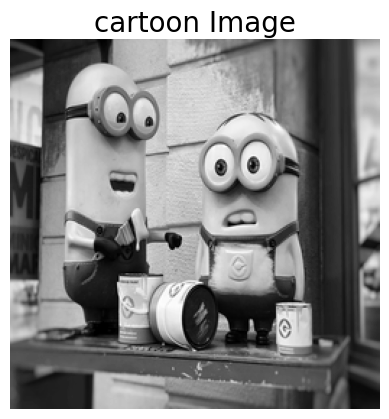

In [25]:
cartoon_img = load_image("images/justin-lim-tloFnD-7EpI-unsplash.jpg")
cartoon_normal = normalize_image(cartoon_img)
show_image(cartoon_img, "cartoon Image")

In [26]:
cartoon_rev, cartoon_fwd = reverse_heat_equation(jacobi_9, cartoon_img, 10000)

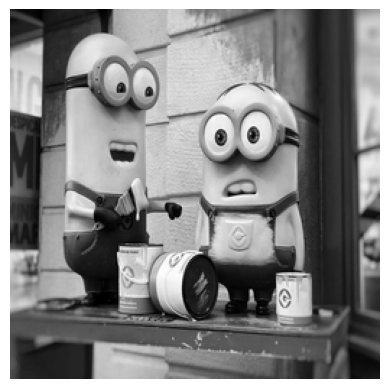

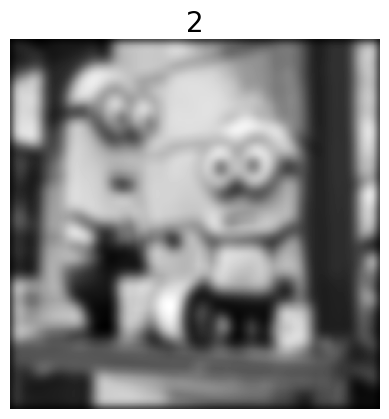

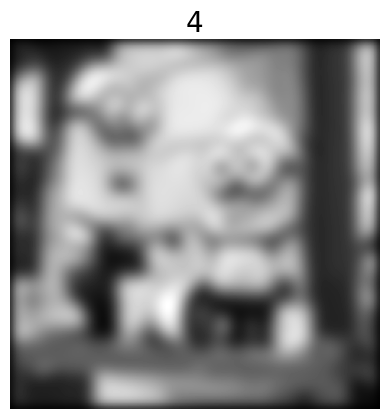

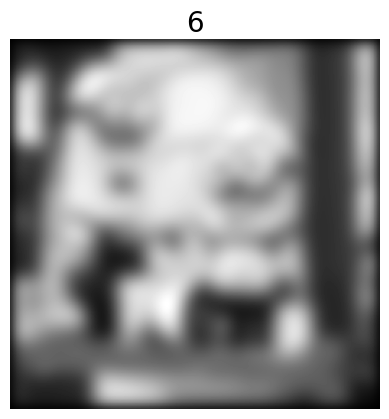

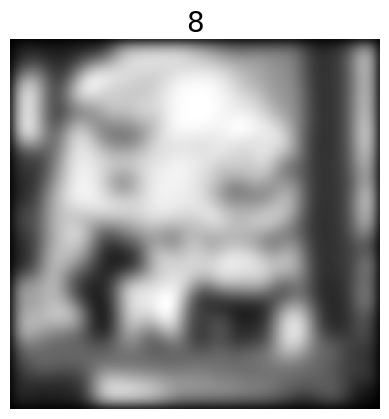

In [27]:
plot_images(cartoon_fwd[0:10], 2)

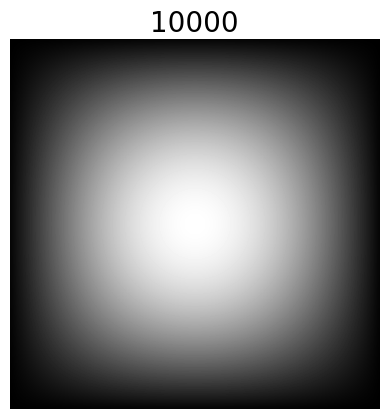

In [28]:
show_image(cartoon_fwd[-1], "10000")

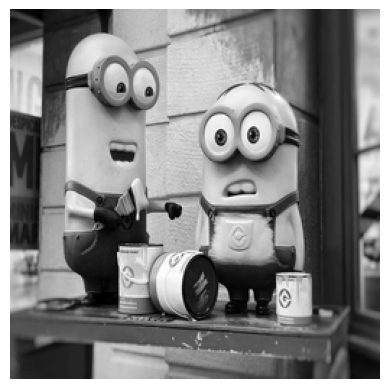

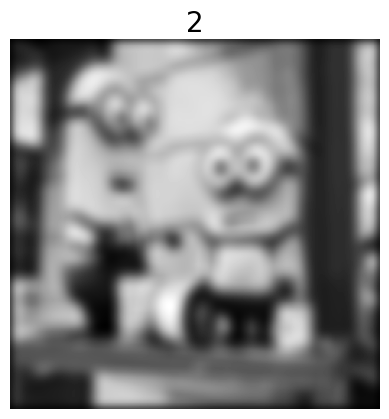

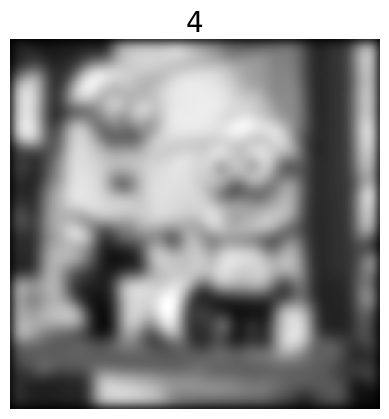

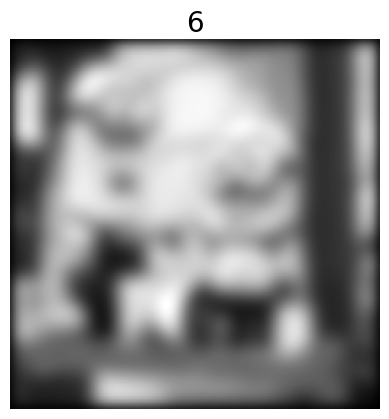

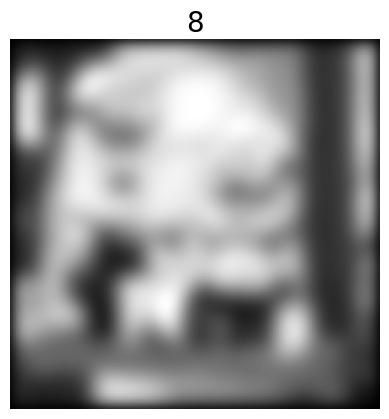

In [29]:
plot_images(cartoon_rev[0:10], 2)

In [30]:
reconstructed_cartoon = normal_range(cartoon_rev[0])

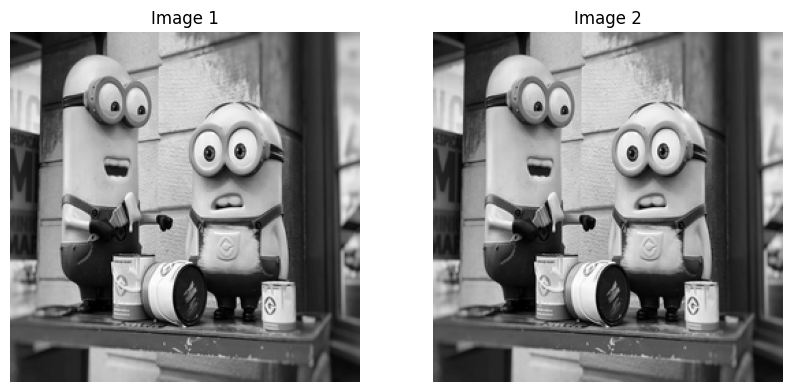

In [31]:
subplot_2(cartoon_img, reconstructed_cartoon)

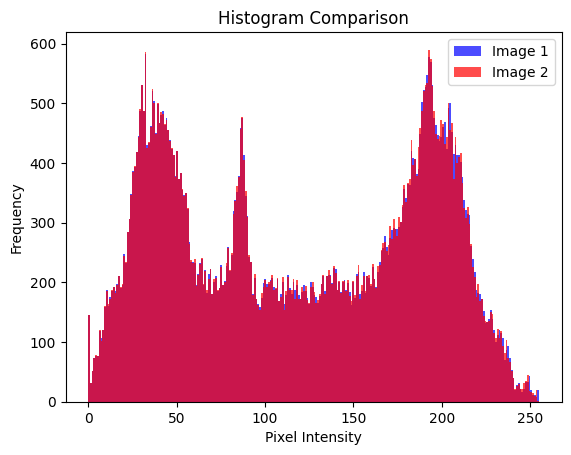

In [32]:
compare_norm_histograms(cartoon_img, reconstructed_cartoon)

In [33]:
mse(cartoon_normal, normalize_image(reconstructed_cartoon)) * 100

0.00017432917177287585

In [34]:
compressed_cartoon, centres_1 = jacobi_compression(reconstructed_cartoon, 8)

In [35]:
compressed_cartoon = normal_range(compressed_cartoon)

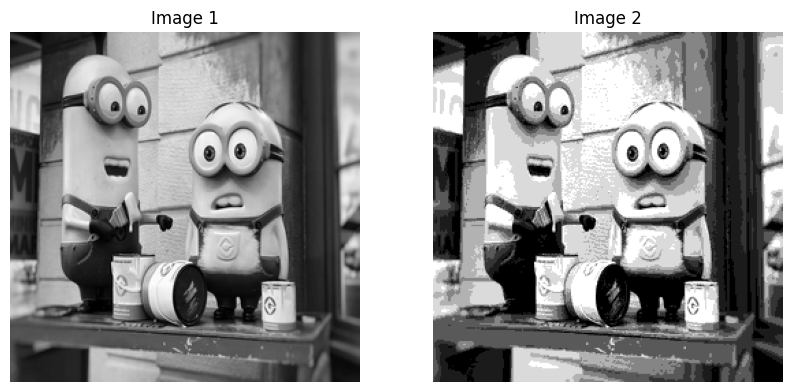

In [36]:
subplot_2(cartoon_img, compressed_cartoon)

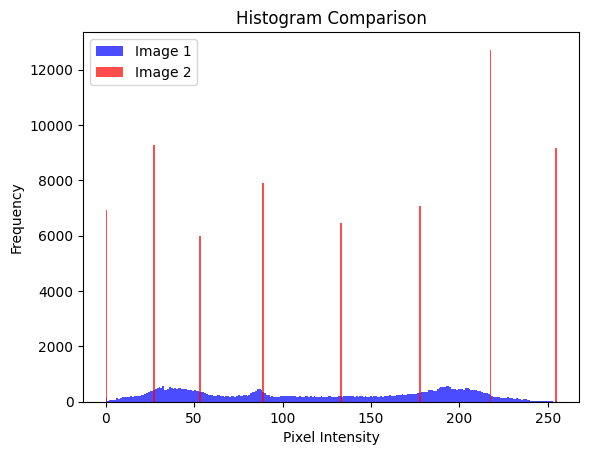

In [37]:
compare_norm_histograms(cartoon_img, compressed_cartoon)

In [38]:
entropy_cartoon = skimage.measure.shannon_entropy(cartoon_img)
entropy_compressed_cartoon = skimage.measure.shannon_entropy(compressed_cartoon)

entropy_cartoon, entropy_compressed_cartoon

(7.788976965715208, 2.9581173957623963)

In [39]:
(
    mse(cartoon_normal, normalize_image(reconstructed_cartoon)) * 100,
    mse(cartoon_normal, normalize_image(compressed_cartoon)) * 100,
)

(0.00017432917177287585, 0.8792225017496275)

### Architecture image (fewer steps)

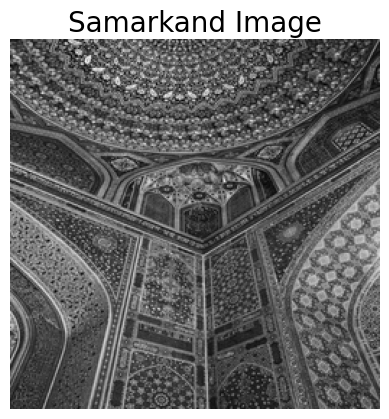

In [40]:
samarkand_img = load_image("images/axp-photography-GQ1fXkYGS40-unsplash.jpg")
samarkand_normal = normalize_image(samarkand_img)
show_image(samarkand_img, "Samarkand Image")

In [41]:
samarkand_rev, samarkand_fwd = reverse_heat_equation(jacobi_9, samarkand_img, 1000)

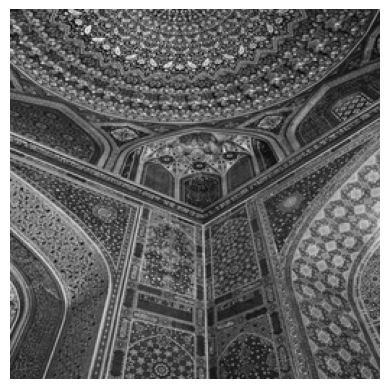

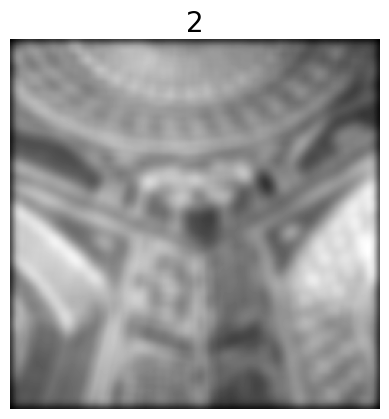

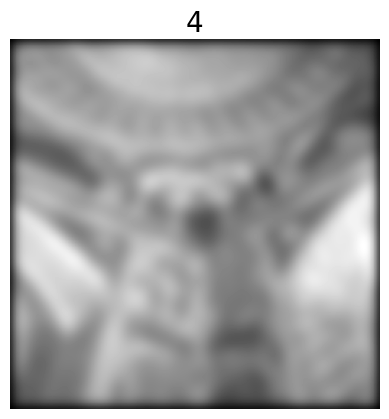

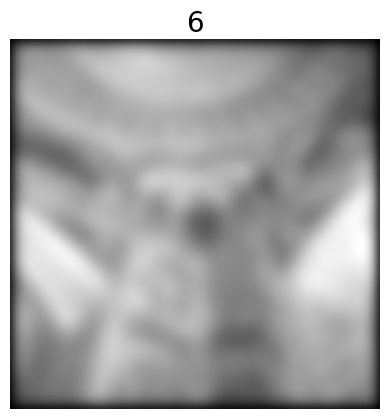

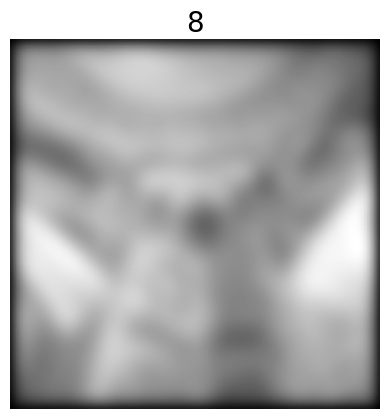

In [42]:
plot_images(samarkand_fwd[0:10], 2)

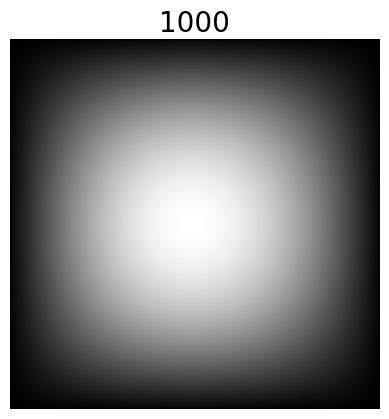

In [43]:
show_image(samarkand_fwd[-1], "1000")

In [44]:
reconstructed_samarkand = normal_range(samarkand_rev[0])

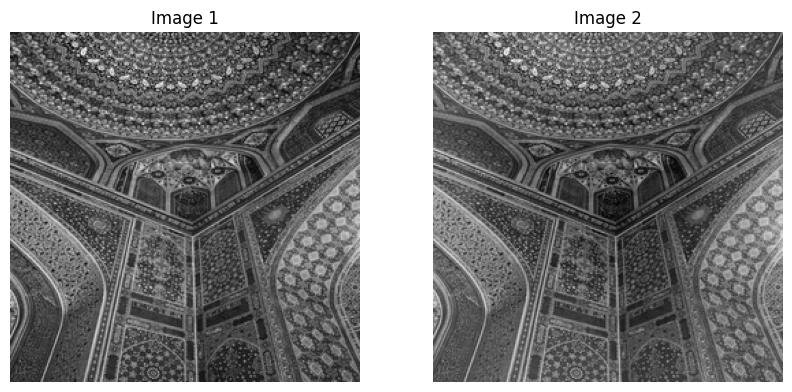

In [45]:
subplot_2(samarkand_img, reconstructed_samarkand)

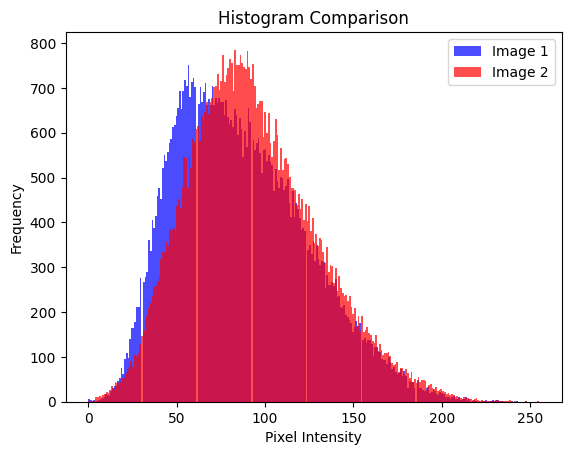

In [46]:
compare_norm_histograms(samarkand_img, reconstructed_samarkand)

In [47]:
mse(samarkand_normal, normalize_image(reconstructed_samarkand))

0.0035060083828476014

In [48]:
compressed_samarkand, centres = jacobi_compression(reconstructed_samarkand, 8)

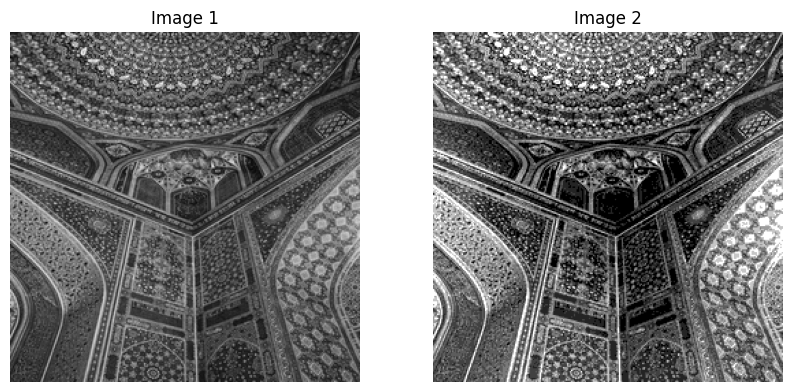

In [49]:
subplot_2(samarkand_img, compressed_samarkand)

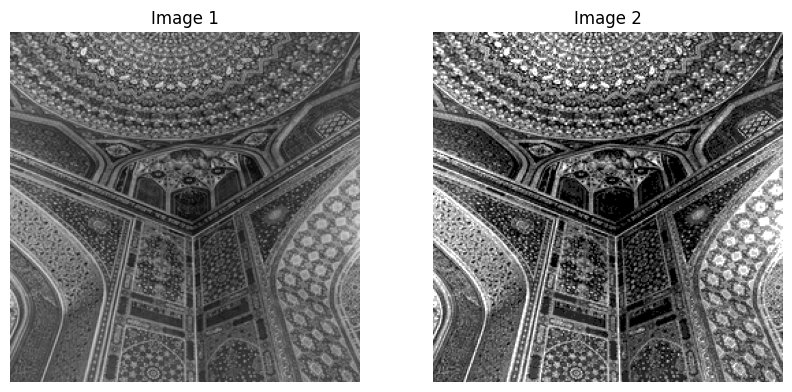

In [50]:
subplot_2(reconstructed_samarkand, compressed_samarkand)

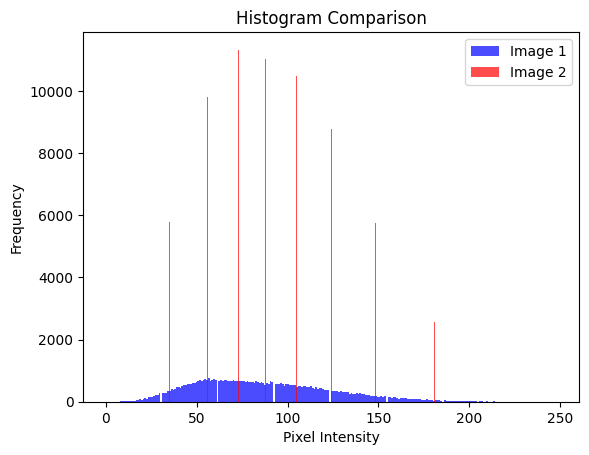

In [51]:
compare_norm_histograms(samarkand_img, compressed_samarkand)

In [52]:
(
    mse(samarkand_normal, normalize_image(compressed_samarkand)),
    mse(samarkand_normal, normalize_image(reconstructed_samarkand)),
)

(0.017792996146455003, 0.0035060083828476014)